#### Exploración de los Datos

In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv("Crime_Population.csv", encoding="utf-8")
# x, y (coordenadas) se usan en Prediccion_SI_Coordenadas; aqui el analisis es por colonia
df = df.drop(columns = ["bien_afectado", "x", "y"])
df.head(25)

Se puede observar que las colonias que no poseen información sobre el censo poblacional del INEGI, son consideradas como muy peligrosas.

In [2]:
# convertimos valor booleano a binario
df["hora_conocida"] = df["hora_conocida"].astype(int)

# 1 si la colonia tiene poblacion del censo, 0 si es NaN
df["poblacion_conocida"] = df["poblacion_colonia"].notna().astype(int)

print(df["hora_conocida"].value_counts())
df["poblacion_conocida"].value_counts()

hora_conocida
1    275878
0     30264
Name: count, dtype: int64


poblacion_conocida
1    282048
0     24094
Name: count, dtype: int64

In [3]:
# tasas de delitos por colonia: total de delitos de cada tipo entre la poblacion de la colonia
delitos_violentos = [
    "Violencia familiar", "Lesiones dolosas", "Abuso sexual infantil",
    "Homicidio doloso", "Violacion", "Feminicidio",
]
delitos_patrimonio = [d for d in df["delito"].unique() if d.startswith("Robo")]

# los nombres de colonia se repiten entre municipios, por eso se agrupa con ambos
llave = ["colonia", "municipio"]

conteo = (
    df.assign(
        n_violence=df["delito"].isin(delitos_violentos).astype(int),
        n_property=df["delito"].isin(delitos_patrimonio).astype(int),
    )
    .groupby(llave)[["n_violence", "n_property"]]
    .transform("sum")
)

# colonias sin poblacion (NaN) quedan con tasa NaN
df["rate_violence"] = conteo["n_violence"] / df["poblacion_colonia"]
df["rate_property"] = conteo["n_property"] / df["poblacion_colonia"]

print("Delitos de patrimonio:", delitos_patrimonio)
df[["colonia", "municipio", "delito", "poblacion_colonia", "rate_violence", "rate_property"]].head(10)

Delitos de patrimonio: ['Robo a carga pesada', 'Robo a int de vehiculos', 'Robo a negocio', 'Robo a persona', 'Robo a vehiculos particulares', 'Robo casa habitacion', 'Robo de autopartes', 'Robo de motocicleta', 'Robo a bancos', 'Robo a cuentahabientes']


,colonia,municipio,delito,poblacion_colonia,rate_violence,rate_property
0,JARDINES DEL BOSQUE,GUADALAJARA,Abuso sexual infantil,6068.0,0.024061,0.131345
1,BALCONES DE SANTA CRUZ,TONALA,Abuso sexual infantil,225.0,0.026667,0.008889
2,EL BETHEL,GUADALAJARA,Abuso sexual infantil,8987.0,0.026817,0.024257
3,CHULAVISTA E1,TLAJOMULCO DE ZUÑIGA,Abuso sexual infantil,NaN,NaN,NaN
4,MIRAVALLE,SAN PEDRO TLAQUEPAQUE,Abuso sexual infantil,24199.0,0.005537,0.011736
5,SANTA MARIA,GUADALAJARA,Abuso sexual infantil,10550.0,0.024739,0.031090
6,SAN ESTEBAN,ZAPOPAN,Abuso sexual infantil,1736.0,0.020161,0.002304
7,SAN PEDRITO,SAN PEDRO TLAQUEPAQUE,Abuso sexual infantil,14689.0,0.040643,0.050718
8,MODERNA,GUADALAJARA,Abuso sexual infantil,4015.0,0.059776,0.343462
9,LOMAS DE POLANCO,GUADALAJARA,Abuso sexual infantil,21615.0,0.026047,0.038954


In [4]:
# bandas horarias: 5 bloques de las 24 horas (0-4, 5-9, 10-14, 15-19, 20-23)
bandas = ["madrugada", "manana", "mediodia", "tarde", "noche"]
df["banda_horaria"] = pd.cut(
    df["hora"],
    bins=[0, 5, 10, 15, 20, 24],
    labels=bandas,
    right=False,      # [0,5), [5,10), ... [20,24)
    include_lowest=True,
)

# las filas con hora desconocida (hora_conocida = 0) quedan como NaN
print(df["banda_horaria"].value_counts(dropna=False).reindex(bandas + [np.nan]))
#df = df.sort_values(by = "rate_violence", ascending = False)
df.head(50)

banda_horaria
madrugada    27368
manana       51320
mediodia     66170
tarde        66420
noche        64600
NaN          30264
Name: count, dtype: int64


,delito,colonia,municipio,año,mes,dia,hora,min,hora_conocida,poblacion_colonia,...,relacion_hombres_mujeres,prop_jefatura_femenina,prop_viviendas_deshabitadas,prop_nacidos_otra_entidad,densidad_hab_km2,ocupantes_por_cuarto,poblacion_conocida,rate_violence,rate_property,banda_horaria
0,Abuso sexual infantil,JARDINES DEL BOSQUE,GUADALAJARA,2020,3,8,0.0,0.0,1,6068.0,...,88.760537,0.400566,0.111502,0.188036,4062.987937,0.570,1,0.024061,0.131345,madrugada
1,Abuso sexual infantil,BALCONES DE SANTA CRUZ,TONALA,2020,3,11,0.0,0.0,1,225.0,...,90.677966,0.264151,0.129032,0.084444,17569.450084,1.180,1,0.026667,0.008889,madrugada
2,Abuso sexual infantil,EL BETHEL,GUADALAJARA,2020,3,14,0.0,0.0,1,8987.0,...,97.040123,0.305446,0.066488,0.253143,20985.109749,1.150,1,0.026817,0.024257,madrugada
3,Abuso sexual infantil,CHULAVISTA E1,TLAJOMULCO DE ZUÑIGA,2020,3,14,0.0,0.0,1,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,madrugada
4,Abuso sexual infantil,MIRAVALLE,SAN PEDRO TLAQUEPAQUE,2020,3,16,0.0,0.0,1,24199.0,...,90.917699,0.401552,0.049759,0.103186,17041.008184,0.925,1,0.005537,0.011736,madrugada
5,Abuso sexual infantil,SANTA MARIA,GUADALAJARA,2020,1,14,0.0,0.0,1,10550.0,...,94.901164,0.411241,0.095238,0.076398,14247.656740,0.840,1,0.024739,0.031090,madrugada
6,Abuso sexual infantil,SAN ESTEBAN,ZAPOPAN,2020,9,2,0.0,0.0,1,1736.0,...,100.461894,0.342193,0.071429,0.013249,1119.753582,1.520,1,0.020161,0.002304,madrugada
7,Abuso sexual infantil,SAN PEDRITO,SAN PEDRO TLAQUEPAQUE,2020,1,25,0.0,0.0,1,14689.0,...,97.749023,0.352548,0.134525,0.084008,8509.833049,1.100,1,0.040643,0.050718,madrugada
8,Abuso sexual infantil,MODERNA,GUADALAJARA,2020,11,5,0.0,0.0,1,4015.0,...,92.979872,0.396294,0.178552,0.157659,2246.031323,0.630,1,0.059776,0.343462,madrugada
9,Abuso sexual infantil,LOMAS DE POLANCO,GUADALAJARA,2020,1,4,0.0,0.0,1,21615.0,...,93.560233,0.383653,0.076468,0.105344,16259.220921,0.910,1,0.026047,0.038954,madrugada


In [5]:
# Indice de severidad: SI = N[ alpha * Rv_T + (1 - alpha) * Rp_T ]
# Rv_T / Rp_T: delitos violentos / de robo de la colonia en la banda horaria T, entre su poblacion
ALPHA = 0.7       # peso de severidad: el crimen violento pesa mas que el de propiedad
PERCENTIL = 0.99  # tope para que las colonias con poblacion diminuta no aplasten la escala

llave_T = ["colonia", "municipio", "banda_horaria"]

conteo_T = (
    df.assign(
        n_violence=df["delito"].isin(delitos_violentos).astype(int),
        n_property=df["delito"].isin(delitos_patrimonio).astype(int),
    )
    .groupby(llave_T, observed=True)[["n_violence", "n_property"]]
    .transform("sum")
)

df["Rv_T"] = conteo_T["n_violence"] / df["poblacion_colonia"]
df["Rp_T"] = conteo_T["n_property"] / df["poblacion_colonia"]
df["n_violence"] = conteo_T["n_violence"]
df["n_property"] = conteo_T["n_property"]

def N(x, percentil=PERCENTIL):
    """Escala a [0, 100]: recorta en el percentil dado y aplica min-max."""
    tope = x.quantile(percentil)
    return 100 * (x.clip(upper=tope) - x.min()) / (tope - x.min())

# realizamos el calculo del indice de seguridad para cada una de las filas
df["SI"] = N(ALPHA * df["Rv_T"] + (1 - ALPHA) * df["Rp_T"])

# colonias sin censo del INEGI (poblacion NaN) se consideran de maxima peligrosidad
#df.loc[df["poblacion_colonia"].isna(), "SI"] = 100

# SI sigue en NaN solo si la hora es desconocida (y la colonia si tiene poblacion)
print(df["SI"].describe())
df.groupby("banda_horaria", observed=True)["SI"].mean()

count    257185.000000
mean         13.978688
std          16.603135
min           0.000000
25%           6.204868
50%           8.933766
75%          13.527511
max         100.000000
Name: SI, dtype: float64


banda_horaria
madrugada     7.289676
manana       10.631161
mediodia     15.741565
tarde        16.664551
noche        14.898005
Name: SI, dtype: float64

In [6]:
# Rv_T, Rp_T y SI ya se calcularon con todos los delitos; ahora se quitan las filas de robo
# y las de abuso sexual infantil (78% de sus registros no tiene hora)
n_inicial = len(df)
df = df[~df["delito"].isin(delitos_patrimonio + ["Abuso sexual infantil"])]

# se quitan los registros sin hora conocida o sin poblacion de la colonia
n_filtrado = len(df)
df = df.dropna(subset=["banda_horaria", "poblacion_colonia"])

# y los registros duplicados exactos (mismo delito, colonia, fecha y hora)
# se hace antes de quitar las columnas de fecha/hora, porque las usa para comparar
n_completos = len(df)
df = df.drop_duplicates().reset_index(drop=True)

# la informacion temporal ya esta resumida en banda_horaria
df = df.drop(columns=["año", "mes", "dia", "hora", "min"])

print(f"Filas originales:      {n_inicial}")
print(f"Sin robos ni abuso:    {n_filtrado}  (-{n_inicial - n_filtrado})")
print(f"Con hora y poblacion:  {n_completos}  (-{n_filtrado - n_completos})")
print(f"Sin duplicados:        {len(df)}  (-{n_completos - len(df)})")
print("Columnas:", list(df.columns))
df["delito"].value_counts()

Filas originales:      306142
Sin robos ni abuso:    109439  (-196703)
Con hora y poblacion:  92310  (-17129)
Sin duplicados:        92137  (-173)
Columnas: ['delito', 'colonia', 'municipio', 'hora_conocida', 'poblacion_colonia', 'poblacion_femenina', 'poblacion_masculina', 'Total de viviendas habitadas', 'Grado promedio de escolaridad', 'Viviendas particulares habitadas que disponen de Internet', 'tasa_desempleo', 'prop_sin_salud', 'prop_sin_vehiculo', 'prop_internet', 'prop_18_24', 'relacion_hombres_mujeres', 'prop_jefatura_femenina', 'prop_viviendas_deshabitadas', 'prop_nacidos_otra_entidad', 'densidad_hab_km2', 'ocupantes_por_cuarto', 'poblacion_conocida', 'rate_violence', 'rate_property', 'banda_horaria', 'Rv_T', 'Rp_T', 'n_violence', 'n_property', 'SI']


delito
Violencia familiar    53589
Lesiones dolosas      30019
Homicidio doloso       6290
Violacion              2070
Feminicidio             169
Name: count, dtype: int64

In [7]:
df = df.sort_values(by = "SI", ascending = True)
df = df[df["poblacion_colonia"] >= 1000]
df = df[df["SI"] >= 50]

df = df[df["municipio"] == "GUADALAJARA"]
df = df[df["banda_horaria"] != "manana"]

df = df.drop(columns = ["rate_violence", "rate_property", "delito", "municipio", "hora_conocida", "poblacion_conocida"])
df = df.drop_duplicates()
df.to_csv("population_crime_gdl.csv", index=False)
df.head(55)



,colonia,poblacion_colonia,poblacion_femenina,poblacion_masculina,Total de viviendas habitadas,Grado promedio de escolaridad,Viviendas particulares habitadas que disponen de Internet,tasa_desempleo,prop_sin_salud,prop_sin_vehiculo,...,prop_viviendas_deshabitadas,prop_nacidos_otra_entidad,densidad_hab_km2,ocupantes_por_cuarto,banda_horaria,Rv_T,Rp_T,n_violence,n_property,SI
65543,MODERNA,4015.0,2037.0,1894.0,1418.0,12.81,1119.0,0.016722,0.199502,0.374911,...,0.178552,0.157659,2246.031323,0.63,tarde,0.013450,0.082690,54.0,332.0,52.765680
41009,MODERNA,4015.0,2037.0,1894.0,1418.0,12.81,1119.0,0.016722,0.199502,0.374911,...,0.178552,0.157659,2246.031323,0.63,mediodia,0.015193,0.081694,61.0,328.0,54.187369
8498,AMERICANA,3885.0,1935.0,1905.0,1661.0,14.43,1474.0,0.014700,0.269755,0.276284,...,0.170156,0.214157,2708.415822,0.53,madrugada,0.014157,0.092921,55.0,361.0,58.265015
34590,PRADOS DEL NILO,1083.0,576.0,507.0,310.0,10.90,232.0,0.014035,0.230840,0.367742,...,0.078488,0.099723,5083.092129,0.76,mediodia,0.013850,0.103416,15.0,112.0,62.791161
56031,AMERICANA,3885.0,1935.0,1905.0,1661.0,14.43,1474.0,0.014700,0.269755,0.276284,...,0.170156,0.214157,2708.415822,0.53,tarde,0.014157,0.108623,55.0,422.0,65.531906
25013,ZONA CENTRO,13033.0,6513.0,6383.0,4635.0,12.83,3745.0,0.018222,0.300008,0.526860,...,0.185028,0.174941,4150.464923,0.60,mediodia,0.019412,0.104044,253.0,1356.0,69.087695
37566,AMERICANA,3885.0,1935.0,1905.0,1661.0,14.43,1474.0,0.014700,0.269755,0.276284,...,0.170156,0.214157,2708.415822,0.53,mediodia,0.014672,0.122523,57.0,476.0,72.520828
60624,ZONA CENTRO,13033.0,6513.0,6383.0,4635.0,12.83,3745.0,0.018222,0.300008,0.526860,...,0.185028,0.174941,4150.464923,0.60,tarde,0.025857,0.099824,337.0,1301.0,74.094775
90825,ARCOS VALLARTA,1669.0,859.0,792.0,694.0,14.41,625.0,0.014787,0.255243,0.151825,...,0.169414,0.224086,1815.903191,0.53,noche,0.009587,0.153385,16.0,256.0,81.313060
44264,ARCOS VALLARTA,1669.0,859.0,792.0,694.0,14.41,625.0,0.014787,0.255243,0.151825,...,0.169414,0.224086,1815.903191,0.53,tarde,0.013781,0.156980,23.0,262.0,87.506145


In [8]:
arr = df["colonia"].unique()
print(arr)



print(len(arr))

['MODERNA' 'AMERICANA' 'PRADOS DEL NILO' 'ZONA CENTRO' 'ARCOS VALLARTA']
5


In [9]:
df = df.dropna(subset=["poblacion_colonia"])
df = df.drop(columns=["colonia"])
encoded_df = pd.get_dummies(df, columns = ["banda_horaria"], dtype=int)
encoded_df.head()

,poblacion_colonia,poblacion_femenina,poblacion_masculina,Total de viviendas habitadas,Grado promedio de escolaridad,Viviendas particulares habitadas que disponen de Internet,tasa_desempleo,prop_sin_salud,prop_sin_vehiculo,prop_internet,...,Rv_T,Rp_T,n_violence,n_property,SI,banda_horaria_madrugada,banda_horaria_manana,banda_horaria_mediodia,banda_horaria_tarde,banda_horaria_noche
65543,4015.0,2037.0,1894.0,1418.0,12.81,1119.0,0.016722,0.199502,0.374911,0.797577,...,0.013450,0.082690,54.0,332.0,52.765680,0,0,0,1,0
41009,4015.0,2037.0,1894.0,1418.0,12.81,1119.0,0.016722,0.199502,0.374911,0.797577,...,0.015193,0.081694,61.0,328.0,54.187369,0,0,1,0,0
8498,3885.0,1935.0,1905.0,1661.0,14.43,1474.0,0.014700,0.269755,0.276284,0.900978,...,0.014157,0.092921,55.0,361.0,58.265015,1,0,0,0,0
34590,1083.0,576.0,507.0,310.0,10.90,232.0,0.014035,0.230840,0.367742,0.748387,...,0.013850,0.103416,15.0,112.0,62.791161,0,0,1,0,0
56031,3885.0,1935.0,1905.0,1661.0,14.43,1474.0,0.014700,0.269755,0.276284,0.900978,...,0.014157,0.108623,55.0,422.0,65.531906,0,0,0,1,0


In [10]:
encoded_df = encoded_df.dropna()
encoded_df = encoded_df.drop(columns=["banda_horaria_manana", "SI"]) 

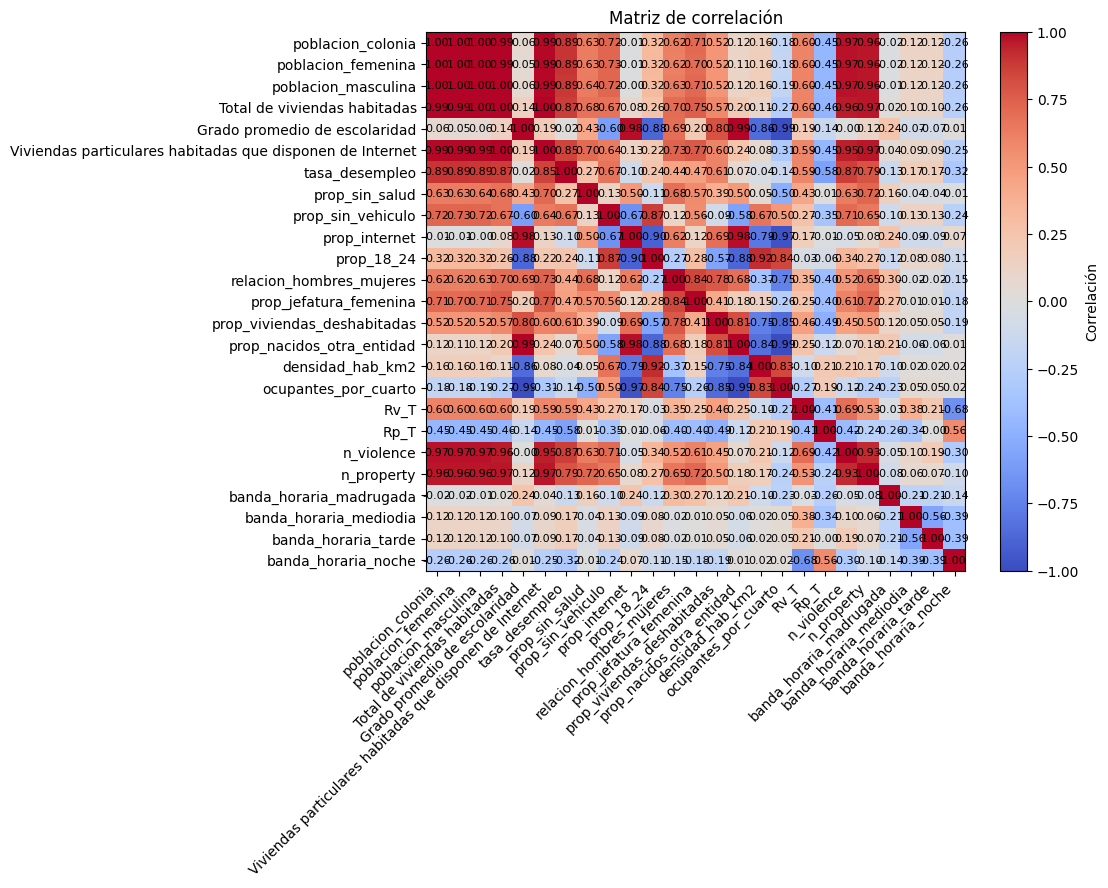

In [11]:
import matplotlib.pyplot as plt
# calculamos la correlacion entre todas las variables numericas
df_corr = encoded_df.copy()
# utilizamos pandas para calcular la correlación que hay entre los coeficientes
corr_matrix = df_corr.corr()

# heatmap con matplotlib puro (sin necesidad de seaborn)
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

# etiquetas de los ejes
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=45, ha="right")
ax.set_yticklabels(corr_matrix.columns)

# escribir el valor numérico dentro de cada celda
for i in range(len(corr_matrix.columns)):
    for j in range(len(corr_matrix.columns)):
        ax.text(j, i, f"{corr_matrix.iloc[i, j]:.2f}",
                 ha="center", va="center", color="black", fontsize=8)

fig.colorbar(im, ax=ax, label="Correlación")
plt.title("Matriz de correlación")
#plt.tight_layout()
plt.show()

In [12]:
# Modelo: predecir el SI de cada colonia en cada banda horaria a partir del censo
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GroupKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# se vuelve a leer el csv: las celdas anteriores dejaron df filtrado a 7 colonias
dm = pd.read_csv("Crime_Population.csv", encoding="utf-8")
dm["banda_horaria"] = pd.cut(dm["hora"], bins=[0, 5, 10, 15, 20, 24], labels=bandas,
                             right=False).astype("object")
dm["n_violence"] = dm["delito"].isin(delitos_violentos).astype(int)
dm["n_property"] = dm["delito"].isin(delitos_patrimonio).astype(int)
llave = ["colonia", "municipio"]

# escala del SI: mismo tope y minimo que la celda del indice (calculados sobre los delitos),
# para que el SI del modelo sea el mismo SI del notebook
cnt = dm.groupby(llave + ["banda_horaria"])[["n_violence", "n_property"]].transform("sum")
x_fila = (ALPHA * cnt["n_violence"] + (1 - ALPHA) * cnt["n_property"]) / dm["poblacion_colonia"]
tope, piso = x_fila.quantile(PERCENTIL), x_fila.min()

# solo variables del censo: Rv_T, Rp_T, n_violence, n_property y rate_* salen de los
# mismos delitos que forman el SI (usarlas seria data leakage)
features_censo = ["poblacion_colonia", "Grado promedio de escolaridad", "tasa_desempleo",
                  "prop_sin_salud", "prop_sin_vehiculo", "prop_internet", "prop_18_24",
                  "relacion_hombres_mujeres", "prop_jefatura_femenina",
                  "prop_viviendas_deshabitadas", "prop_nacidos_otra_entidad",
                  "densidad_hab_km2", "ocupantes_por_cuarto"]
colonias = dm.groupby(llave)[features_censo].first().dropna()
# con menos de 1000 habitantes un par de delitos dispara la tasa
colonias = colonias[colonias["poblacion_colonia"] >= 1000]

# una fila por colonia x banda; las bandas sin delitos entran con conteo 0 (SI = 0).
# Si solo se usaran las que tuvieron delitos, el modelo nunca veria colonias tranquilas
conteos = dm.dropna(subset=["banda_horaria"]).groupby(llave + ["banda_horaria"])[
    ["n_violence", "n_property"]].sum()
malla = pd.MultiIndex.from_tuples([(c, m, b) for c, m in colonias.index for b in bandas],
                                  names=llave + ["banda_horaria"])
datos = conteos.reindex(malla, fill_value=0).reset_index().merge(colonias.reset_index(), on=llave)

x = (ALPHA * datos["n_violence"] + (1 - ALPHA) * datos["n_property"]) / datos["poblacion_colonia"]
datos["SI"] = (100 * (x.clip(upper=tope) - piso) / (tope - piso)).clip(lower=0)

X = pd.get_dummies(datos[features_censo + ["banda_horaria"]], columns=["banda_horaria"], dtype=int)
# escala logaritmica: poblacion y densidad van de cientos a decenas de miles
for col in ("poblacion_colonia", "densidad_hab_km2"):
    X[col] = np.log(X[col])
y = datos["SI"]
# validacion por colonia: si Moderna-tarde queda en train y Moderna-noche en test,
# el modelo ya "conoce" Moderna y el error sale enganosamente bajo
grupos = datos["colonia"] + "|" + datos["municipio"]

modelos = {
    "Promedio (baseline)": DummyRegressor(),
    "Regresion lineal":    make_pipeline(StandardScaler(), LinearRegression()),
    # hojas grandes y la mitad de variables por corte: con min_samples_leaf=5 sobreajusta (R2 0.25)
    "Random Forest":       RandomForestRegressor(n_estimators=300, min_samples_leaf=20,
                                                 max_features=0.5, n_jobs=-1, random_state=0),
}
cv = GroupKFold(n_splits=5)
resultados = {}
for nombre, modelo in modelos.items():
    r = cross_validate(modelo, X, y, groups=grupos, cv=cv,
                       scoring=["r2", "neg_mean_absolute_error", "neg_root_mean_squared_error"])
    resultados[nombre] = {"R2": r["test_r2"].mean(),
                          "MAE": -r["test_neg_mean_absolute_error"].mean(),
                          "RMSE": -r["test_neg_root_mean_squared_error"].mean()}

print(f"{len(colonias)} colonias x {len(bandas)} bandas = {len(datos)} filas")
print(f"SI: media {y.mean():.1f}, mediana {y.median():.1f}, {(y == 0).mean():.0%} en cero\n")
print(pd.DataFrame(resultados).T.round(3).to_string())

# importancia por permutacion en colonias que el modelo no vio al entrenar
entrena, prueba = next(cv.split(X, y, grupos))
rf = modelos["Random Forest"].fit(X.iloc[entrena], y.iloc[entrena])
imp = permutation_importance(rf, X.iloc[prueba], y.iloc[prueba], n_repeats=10,
                             random_state=0, n_jobs=-1)
importancia = pd.Series(imp.importances_mean, index=X.columns).sort_values(ascending=False)
print("\nImportancia (caida de R2 al revolver cada variable):")
print(importancia.round(3).to_string())

1033 colonias x 5 bandas = 5165 filas
SI: media 6.6, mediana 5.4, 3% en cero

                        R2    MAE   RMSE
Promedio (baseline) -0.008  3.978  6.481
Regresion lineal     0.193  3.406  5.786
Random Forest        0.197  3.257  5.791

Importancia (caida de R2 al revolver cada variable):
banda_horaria_madrugada          0.132
densidad_hab_km2                 0.103
prop_sin_vehiculo                0.061
ocupantes_por_cuarto             0.028
banda_horaria_manana             0.027
prop_jefatura_femenina           0.019
Grado promedio de escolaridad    0.011
prop_sin_salud                   0.009
poblacion_colonia                0.008
relacion_hombres_mujeres         0.003
banda_horaria_tarde              0.002
prop_nacidos_otra_entidad        0.001
banda_horaria_noche              0.001
banda_horaria_mediodia           0.000
prop_internet                   -0.001
prop_viviendas_deshabitadas     -0.002
tasa_desempleo                  -0.004
prop_18_24                      -0.017


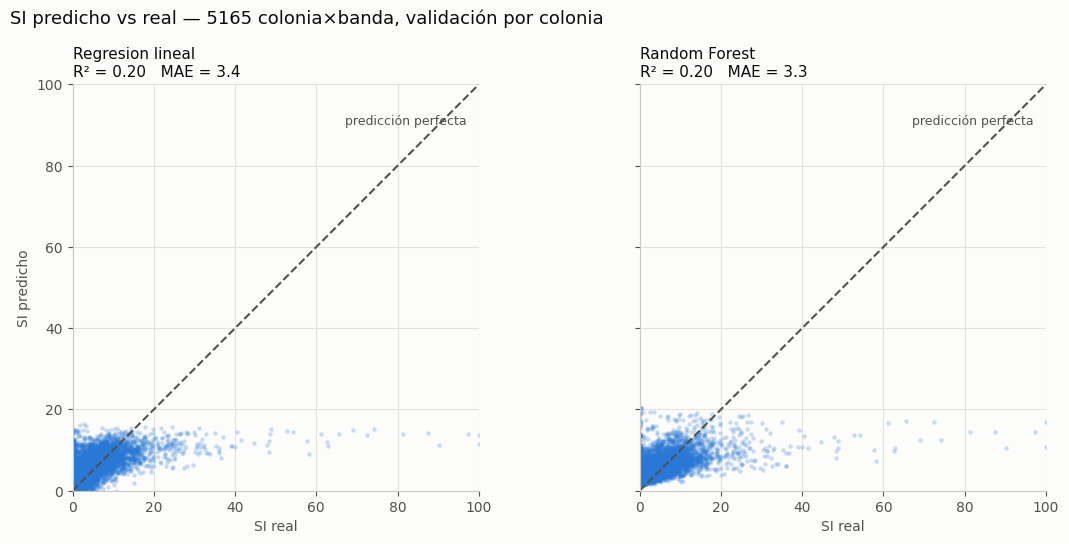

In [13]:
# SI predicho vs SI real. Predicciones out-of-fold: cada colonia la predice el modelo
# que no la vio al entrenar, igual que en la validacion de arriba
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_predict

AZUL, TINTA, TINTA_2, FONDO = "#2a78d6", "#0b0b0b", "#52514e", "#fcfcfb"

graficar = ["Regresion lineal", "Random Forest"]
limite = max(y.max(), 60)
fig, axes = plt.subplots(1, len(graficar), figsize=(12, 5.5), sharex=True, sharey=True,
                         facecolor=FONDO)

for ax, nombre in zip(axes, graficar):
    pred = cross_val_predict(modelos[nombre], X, y, groups=grupos, cv=cv)
    ax.set_facecolor(FONDO)
    ax.scatter(y, pred, s=10, alpha=0.25, color=AZUL, linewidths=0)
    # referencia: sobre esta linea la prediccion es exacta
    ax.plot([0, limite], [0, limite], color=TINTA_2, linewidth=1.5, linestyle="--")
    ax.text(limite * 0.97, limite * 0.90, "predicción perfecta", color=TINTA_2,
            ha="right", fontsize=9)
    ax.set_title(f"{nombre}\nR² = {r2_score(y, pred):.2f}   MAE = {mean_absolute_error(y, pred):.1f}",
                 color=TINTA, fontsize=11, loc="left")
    ax.set_xlabel("SI real", color=TINTA_2)
    ax.set_xlim(0, limite)
    ax.set_ylim(0, limite)
    ax.set_aspect("equal")
    ax.grid(color="#e4e3df", linewidth=0.8)
    ax.set_axisbelow(True)
    ax.tick_params(colors=TINTA_2)
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)
    for lado in ("left", "bottom"):
        ax.spines[lado].set_color("#c9c8c3")

axes[0].set_ylabel("SI predicho", color=TINTA_2)
fig.suptitle(f"SI predicho vs real — {len(datos)} colonia×banda, validación por colonia",
             color=TINTA, fontsize=13, x=0.06, ha="left")
fig.tight_layout()
plt.show()